# Additional pair features: contact time, daily inbound texts, and minimum call time

This notebook engineers and analyzes three additional features for unordered
participant pairs in the Copenhagen Networks Study:

1. **Elapsed in-person contact:** cumulative minutes in unique five-minute
   Bluetooth bins with RSSI greater than −75 dBm.
2. **Combined daily texts received:** the two participants' average inbound
   texts per study day, received from any study participant.
3. **Minimum call contact time:** the shortest completed call between the pair;
   missed calls (`duration == -1`) are excluded and pairs without a completed
   call remain missing.

The pair universe matches the existing relationship work: every valid pair
observed in Bluetooth, SMS, calls, or the Facebook edge list. Facebook
friendship is used only as an analysis label.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PAIR_KEYS = ['user_a', 'user_b']
SECONDS_PER_DAY = 86_400
FIVE_MINUTES = 300
STUDY_DAYS = 28
RSSI_CLOSE_THRESHOLD = -75

# Works when launched from the repository root or from FinalProject/notebooks.
cwd = Path.cwd()
if (cwd / 'FinalProject' / 'data' / 'raw').exists():
    PROJECT_DIR = cwd / 'FinalProject'
elif (cwd.parent / 'data' / 'raw').exists():
    PROJECT_DIR = cwd.parent
else:
    raise FileNotFoundError('Could not locate FinalProject/data/raw')

RAW_DIR = PROJECT_DIR / 'data' / 'raw'
INTERIM_DIR = PROJECT_DIR / 'data' / 'interim'

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#BDBDBD',
    'axes.labelcolor': '#222222',
    'text.color': '#222222',
    'xtick.color': '#444444',
    'ytick.color': '#444444',
    'font.size': 10,
})

print(f'Raw data directory: {RAW_DIR}')

Raw data directory: /Users/vincentlu/26-the-deep-learners-analysis/FinalProject/data/raw


In [2]:
def read_cns_csv(filename):
    data = pd.read_csv(RAW_DIR / filename)
    return data.rename(columns=lambda column: str(column).removeprefix('# ').strip())

calls_data = read_cns_csv('calls.csv')
bt_data = read_cns_csv('bt_symmetric.csv')
sms_data = read_cns_csv('sms.csv')
fb_data = read_cns_csv('fb_friends.csv')

print(
    f"Loaded {len(bt_data):,} Bluetooth rows, {len(sms_data):,} SMS rows, "
    f"{len(calls_data):,} call rows, and {len(fb_data):,} Facebook rows."
)

Loaded 5,474,289 Bluetooth rows, 24,333 SMS rows, 3,600 call rows, and 6,429 Facebook rows.


In [3]:
def make_undirected_pairs(data, left_column, right_column, retained_columns=()):
    columns = [left_column, right_column, *retained_columns]
    pairs = data[columns].copy()
    left = pairs[left_column].to_numpy()
    right = pairs[right_column].to_numpy()
    pairs['user_a'] = np.minimum(left, right)
    pairs['user_b'] = np.maximum(left, right)
    valid = pairs['user_a'].ge(0) & pairs['user_a'].lt(pairs['user_b'])
    return pairs.loc[valid].copy()

bt_pairs = make_undirected_pairs(
    bt_data.loc[bt_data['user_b'].ge(0)],
    'user_a', 'user_b', ('timestamp', 'rssi'),
)
sms_pairs = make_undirected_pairs(
    sms_data, 'sender', 'recipient', ('timestamp',),
)
call_pairs = make_undirected_pairs(
    calls_data, 'caller', 'callee', ('timestamp', 'duration'),
)
fb_pairs = (
    make_undirected_pairs(fb_data, 'user_a', 'user_b')[PAIR_KEYS]
    .drop_duplicates()
)

pair_universe = (
    pd.concat(
        [
            bt_pairs[PAIR_KEYS],
            sms_pairs[PAIR_KEYS],
            call_pairs[PAIR_KEYS],
            fb_pairs,
        ],
        ignore_index=True,
    )
    .drop_duplicates()
    .sort_values(PAIR_KEYS)
    .reset_index(drop=True)
)

print(f'Pair universe: {len(pair_universe):,} unordered pairs')
print(f'Confirmed Facebook-friend pairs: {len(fb_pairs):,}')

Pair universe: 82,851 unordered pairs
Confirmed Facebook-friend pairs: 6,418


## Feature 1 — elapsed in-person contact

Bluetooth scans occur approximately every five minutes. Multiple records in
the same pair/bin are reduced to one observation so the same five-minute
interval is not counted twice.

\[
\text{contact minutes}_{ij}
= 5 \times \text{unique close pair-bins}_{ij}
\]

This is an estimate of cumulative close-contact time, not exact continuous
duration.

In [4]:
close_bt = bt_pairs.loc[bt_pairs['rssi'].gt(RSSI_CLOSE_THRESHOLD)].copy()
close_bt['five_minute_bin'] = (
    close_bt['timestamp'] // FIVE_MINUTES
).astype('int64')

contact_features = (
    close_bt.drop_duplicates(PAIR_KEYS + ['five_minute_bin'])
    .groupby(PAIR_KEYS)
    .size()
    .mul(5)
    .rename('in_person_contact_minutes')
    .reset_index()
)

print(
    f"{len(contact_features):,} pairs have at least one close-contact bin "
    f"(RSSI > {RSSI_CLOSE_THRESHOLD} dBm)."
)

21,318 pairs have at least one close-contact bin (RSSI > -75 dBm).


## Feature 2 — combined daily texts received

For each participant, inbound texts from any study participant are counted
across the full four-week window and divided by 28. The pair feature is the sum
of the two participants' daily averages:

\[
\text{combined daily inbound texts}_{ij}
= \frac{\text{received texts}_i + \text{received texts}_j}{28}
\]

This measures the pair members' overall texting activity. It does not measure
texts exchanged specifically between the pair.

In [ ]:
daily_texts_received = (
    sms_data.groupby('recipient').size().div(STUDY_DAYS)
)

text_features = pair_universe.copy()
text_features['user_a_daily_texts_received'] = (
    text_features['user_a'].map(daily_texts_received).fillna(0)
)
text_features['user_b_daily_texts_received'] = (
    text_features['user_b'].map(daily_texts_received).fillna(0)
)
text_features['combined_daily_texts_received'] = (
    text_features['user_a_daily_texts_received']
    + text_features['user_b_daily_texts_received']
)

print(
    'Median combined daily inbound texts: '
    f"{text_features['combined_daily_texts_received'].median():.2f}"
)


Median combined daily inbound texts: 1.18


## Feature 3 — minimum call contact time

Only completed calls (`duration >= 0`) are used. For pairs with no completed
call, the value remains missing and `has_completed_call` is false. Keeping the
missing value avoids confusing “no completed call” with a real zero-second
call.

In [6]:
minimum_call_features = (
    call_pairs.loc[call_pairs['duration'].ge(0)]
    .groupby(PAIR_KEYS)['duration']
    .min()
    .rename('minimum_call_contact_time_seconds')
    .reset_index()
)

print(f'{len(minimum_call_features):,} pairs have at least one completed call.')

605 pairs have at least one completed call.


## Assemble and export the pair-feature table

In [7]:
pair_features = (
    pair_universe
    .merge(contact_features, on=PAIR_KEYS, how='left')
    .merge(
        text_features[
            PAIR_KEYS
            + [
                'user_a_daily_texts_received',
                'user_b_daily_texts_received',
                'combined_daily_texts_received',
            ]
        ],
        on=PAIR_KEYS,
        how='left',
    )
    .merge(minimum_call_features, on=PAIR_KEYS, how='left')
)

pair_features['in_person_contact_minutes'] = (
    pair_features['in_person_contact_minutes'].fillna(0).astype('int64')
)
pair_features['has_completed_call'] = (
    pair_features['minimum_call_contact_time_seconds'].notna()
)

facebook_edges = set(map(tuple, fb_pairs[PAIR_KEYS].to_numpy()))
pair_features['is_fb_friend'] = [
    tuple(pair) in facebook_edges
    for pair in pair_features[PAIR_KEYS].to_numpy()
]

assert len(pair_features) == len(pair_universe)
assert not pair_features[PAIR_KEYS].duplicated().any()
assert pair_features['user_a'].lt(pair_features['user_b']).all()

INTERIM_DIR.mkdir(parents=True, exist_ok=True)
output_path = INTERIM_DIR / 'additional_pair_features.csv'
pair_features.to_csv(output_path, index=False)

print(f'Saved {len(pair_features):,} rows to {output_path}')
print(pair_features.head(8).to_string(index=False))

Saved 82,851 rows to /Users/vincentlu/26-the-deep-learners-analysis/FinalProject/data/interim/additional_pair_features.csv
 user_a  user_b  in_person_contact_minutes  user_a_daily_texts_received  user_b_daily_texts_received  combined_daily_texts_received  minimum_call_contact_time_seconds  has_completed_call  is_fb_friend
      0       3                          0                     2.642857                     5.250000                       7.892857                                NaN               False         False
      0       5                          0                     2.642857                     0.642857                       3.285714                                NaN               False         False
      0      10                          0                     2.642857                     0.000000                       2.642857                                NaN               False         False
      0      12                          0                     2.642857  

## Descriptive comparison: Facebook friends vs. nonfriends

In [8]:
summary_rows = []
for friend_status, group in pair_features.groupby('is_fb_friend'):
    label = 'Facebook friends' if friend_status else 'Not Facebook friends'
    summary_rows.append({
        'group': label,
        'pairs': len(group),
        'mean contact minutes': group['in_person_contact_minutes'].mean(),
        'median contact minutes': group['in_person_contact_minutes'].median(),
        'mean combined daily inbound texts': group['combined_daily_texts_received'].mean(),
        'median combined daily inbound texts': group['combined_daily_texts_received'].median(),
        'pairs with completed call': group['has_completed_call'].sum(),
        'median minimum call seconds': group['minimum_call_contact_time_seconds'].median(),
    })

summary_table = pd.DataFrame(summary_rows).set_index('group')
print(summary_table.round(2).to_string())

                      pairs  mean contact minutes  median contact minutes  mean combined daily inbound texts  median combined daily inbound texts  pairs with completed call  median minimum call seconds
group                                                                                                                                                                                                    
Not Facebook friends  76433                 11.32                     0.0                               2.92                                 1.18                        116                          5.0
Facebook friends       6418                157.29                     0.0                               3.02                                 1.14                        489                          2.0


## Univariate association with Facebook friendship

ROC-AUC is reported only as a descriptive ranking measure. An AUC near 0.50
means the feature does not separate friends from nonfriends by itself. For
minimum call duration, missing values are filled with zero only for this
diagnostic; the exported feature remains missing.

In [9]:
def rank_auc(labels, values):
    labels = np.asarray(labels, dtype=bool)
    ranks = pd.Series(np.asarray(values)).rank(method='average').to_numpy()
    positive_count = labels.sum()
    negative_count = len(labels) - positive_count
    return (
        ranks[labels].sum()
        - positive_count * (positive_count + 1) / 2
    ) / (positive_count * negative_count)

association_rows = []
feature_tests = [
    (
        'Elapsed in-person contact',
        pair_features['in_person_contact_minutes'],
        pair_features['in_person_contact_minutes'].gt(0),
    ),
    (
        'Combined daily inbound texts',
        pair_features['combined_daily_texts_received'],
        pair_features['combined_daily_texts_received'].gt(0),
    ),
    (
        'Minimum completed-call duration',
        pair_features['minimum_call_contact_time_seconds'].fillna(0),
        pair_features['has_completed_call'],
    ),
]

for name, values, observed in feature_tests:
    association_rows.append({
        'feature': name,
        'univariate ROC-AUC': rank_auc(pair_features['is_fb_friend'], values),
        'pairs with observed/positive feature': int(observed.sum()),
        'friend rate when observed/positive': pair_features.loc[
            observed, 'is_fb_friend'
        ].mean(),
        'friend rate when absent/zero': pair_features.loc[
            ~observed, 'is_fb_friend'
        ].mean(),
    })

association_table = pd.DataFrame(association_rows).set_index('feature')
print(association_table.round(4).to_string())

                                 univariate ROC-AUC  pairs with observed/positive feature  friend rate when observed/positive  friend rate when absent/zero
feature                                                                                                                                                    
Elapsed in-person contact                    0.5935                                 21318                              0.1131                        0.0651
Combined daily inbound texts                 0.4902                                 79489                              0.0757                        0.1184
Minimum completed-call duration              0.5210                                   605                              0.8083                        0.0721


## Friend rate across feature levels

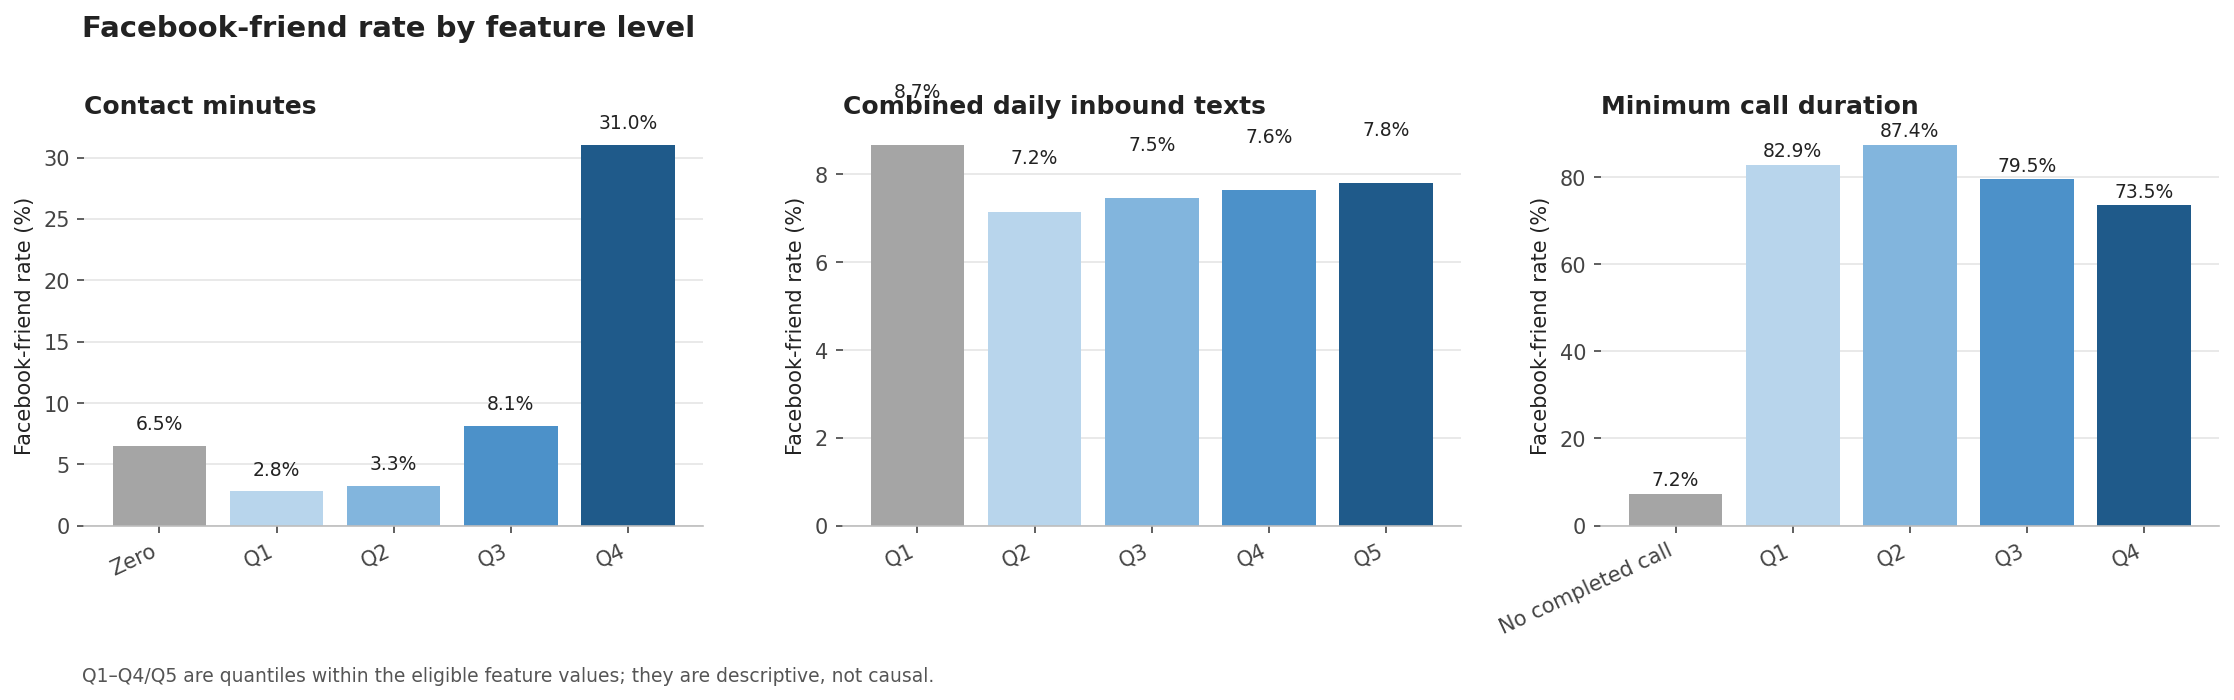

In [10]:
def binned_friend_rates():
    chart_tables = {}

    contact_positive = pair_features['in_person_contact_minutes'].gt(0)
    contact_bins = pd.Series('Zero', index=pair_features.index)
    contact_bins.loc[contact_positive] = pd.qcut(
        pair_features.loc[contact_positive, 'in_person_contact_minutes'].rank(method='first'),
        4,
        labels=['Q1', 'Q2', 'Q3', 'Q4'],
    ).astype(str)
    chart_tables['Contact minutes'] = (
        pair_features.assign(bin=contact_bins)
        .groupby('bin')['is_fb_friend']
        .agg(['size', 'mean'])
        .reindex(['Zero', 'Q1', 'Q2', 'Q3', 'Q4'])
    )

    text_bins = pd.qcut(
        pair_features['combined_daily_texts_received'].rank(method='first'),
        5,
        labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'],
    )
    chart_tables['Combined daily inbound texts'] = (
        pair_features.assign(bin=text_bins)
        .groupby('bin', observed=True)['is_fb_friend']
        .agg(['size', 'mean'])
    )

    completed = pair_features['has_completed_call']
    call_bins = pd.Series('No completed call', index=pair_features.index)
    call_bins.loc[completed] = pd.qcut(
        pair_features.loc[completed, 'minimum_call_contact_time_seconds'].rank(method='first'),
        4,
        labels=['Q1', 'Q2', 'Q3', 'Q4'],
    ).astype(str)
    chart_tables['Minimum call duration'] = (
        pair_features.assign(bin=call_bins)
        .groupby('bin')['is_fb_friend']
        .agg(['size', 'mean'])
        .reindex(['No completed call', 'Q1', 'Q2', 'Q3', 'Q4'])
    )
    return chart_tables

chart_tables = binned_friend_rates()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
colors = ['#A5A5A5', '#B8D5EC', '#82B5DD', '#4C91C9', '#1F5A8A']

for ax, (title, table) in zip(axes, chart_tables.items()):
    bars = ax.bar(range(len(table)), 100 * table['mean'], color=colors[:len(table)])
    ax.set_xticks(range(len(table)), table.index, rotation=25, ha='right')
    ax.set_title(title, loc='left', fontweight='bold')
    ax.set_ylabel('Facebook-friend rate (%)')
    ax.grid(axis='y', color='#E5E5E5', linewidth=0.8)
    ax.set_axisbelow(True)
    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
    for bar, rate in zip(bars, 100 * table['mean']):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(1, ax.get_ylim()[1] * 0.01),
            f'{rate:.1f}%',
            ha='center',
            va='bottom',
            fontsize=9,
        )

fig.suptitle(
    'Facebook-friend rate by feature level',
    x=0.04,
    ha='left',
    fontsize=14,
    fontweight='bold',
)
fig.text(
    0.04,
    -0.03,
    'Q1–Q4/Q5 are quantiles within the eligible feature values; they are descriptive, not causal.',
    fontsize=9,
    color='#555555',
)
plt.tight_layout()
plt.show()

## Relationship with the existing behavioral tie-strength index

In [11]:
strength_path = PROJECT_DIR / 'data' / 'processed' / 'friendship_strength_index.csv'
if strength_path.exists():
    strength_scores = pd.read_csv(strength_path)
    confirmed_friends = (
        pair_features.loc[pair_features['is_fb_friend']]
        .merge(
            strength_scores[PAIR_KEYS + ['friendship_strength_index']],
            on=PAIR_KEYS,
            how='left',
        )
    )
    correlation_rows = []
    for feature in [
        'in_person_contact_minutes',
        'combined_daily_texts_received',
        'minimum_call_contact_time_seconds',
    ]:
        correlation_rows.append({
            'feature': feature,
            'nonmissing pairs': confirmed_friends[feature].notna().sum(),
            'Spearman correlation with existing index': confirmed_friends[
                [feature, 'friendship_strength_index']
            ].corr(method='spearman').iloc[0, 1],
        })
    correlation_table = pd.DataFrame(correlation_rows).set_index('feature')
    print(correlation_table.round(3).to_string())
else:
    print('Existing friendship-strength output not found; correlation analysis skipped.')

                                   nonmissing pairs  Spearman correlation with existing index
feature                                                                                      
in_person_contact_minutes                      6418                                     0.953
combined_daily_texts_received                  6418                                     0.198
minimum_call_contact_time_seconds               489                                    -0.349


## Findings

1. **Elapsed close-contact time contains useful signal, especially at the top
   end.** Facebook friends average about 157 contact minutes versus 11 minutes
   for nonfriends, although both medians are zero. Among pairs with positive
   contact, the top contact-time quartile has a 31.0% Facebook-friend rate.

2. **Combined inbound texts from anyone is not a useful pair-level friendship
   indicator by itself.** Its univariate AUC is approximately 0.49, and friend
   rates are nearly flat across activity quintiles. This feature mainly measures
   how text-active the two individuals are, not whether they text one another.

3. **Having any completed call is highly informative; the shortest call length
   is not.** Only 605 pairs have a completed call, but 80.8% of those pairs are
   Facebook friends. Within that selected group, longer minimum call duration
   does not correspond to a higher friend rate. A completed-call indicator is
   therefore more useful than minimum duration alone.

4. **The contact-time correlation with the existing strength index is expected,
   not independent validation.** The correlation is about 0.95 because the
   existing index already includes close-proximity counts and days.

These results describe this four-week observation window and should not be
interpreted causally.